<a href="https://colab.research.google.com/github/eeeewyz/Audio-course/blob/main/2_three_types_audio_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa

In [2]:
import librosa
#以库中存在的一个声音“小号”为例：
array, sampling_rate = librosa.load(librosa.ex("trumpet"))

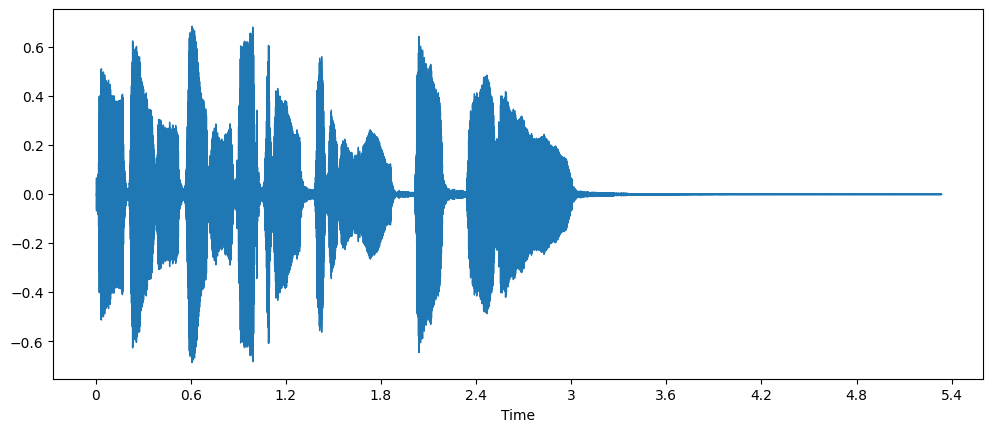

In [3]:
#查看波形
import matplotlib.pyplot as plt
import librosa.display

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

In [12]:
#上传一段我自己的mac上的音频
from google.colab import files

uploaded = files.upload()

Saving common_voice_zh-TW_17367904.mp3 to common_voice_zh-TW_17367904 (2).mp3


In [13]:
array, sampling_rate = librosa.load("common_voice_zh-TW_17367904.mp3")

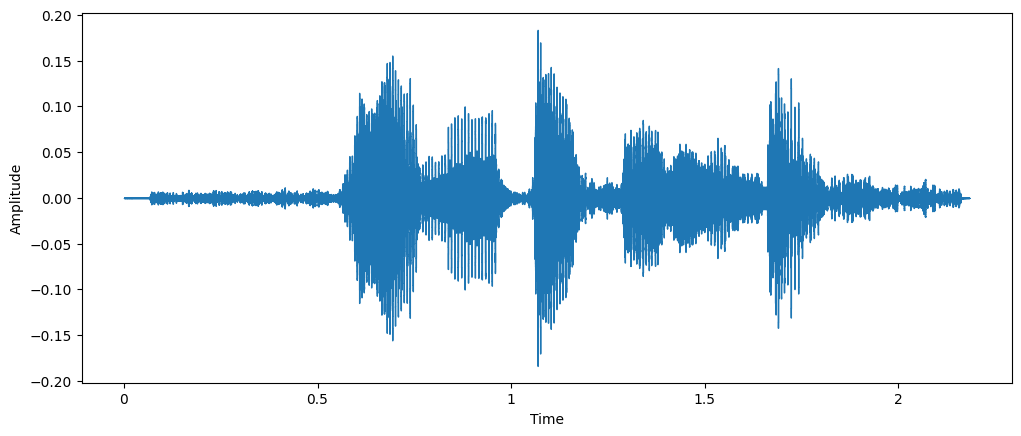

In [14]:
#绘制波形
plt.figure().set_figwidth(12)

librosa.display.waveshow(
    array,
    sr=sampling_rate
)

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [17]:
sampling_rate,array,len(array)

(22050,
 array([-2.1369534e-15,  5.0017412e-16,  2.1272580e-15, ...,
         2.5823488e-09, -7.9973219e-09,  0.0000000e+00], dtype=float32),
 48158)

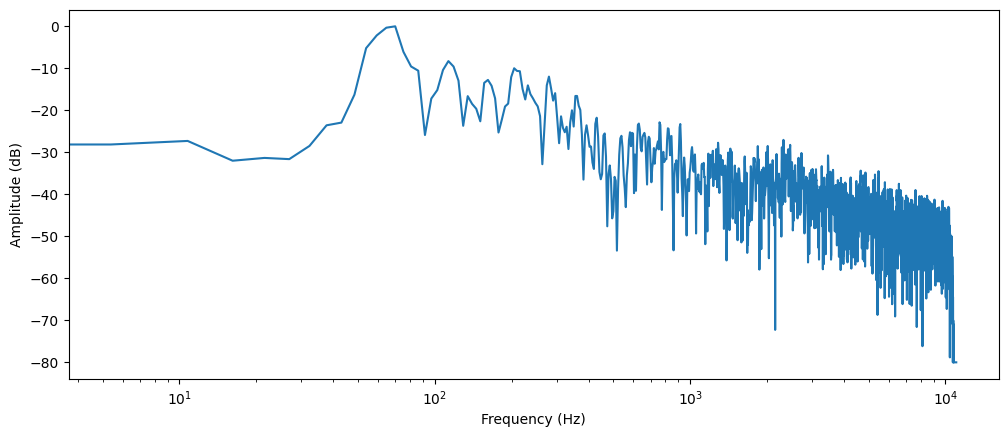

In [19]:
import numpy as np

# 取音频前 4096 个 sample，作为这次 DFT 分析的输入
dft_input = array[:4096]

# -----------------------------
# 1. 计算 DFT / Frequency Spectrum
# -----------------------------

# 生成 Hanning window
# 用来减小截取音频片段边界造成的 spectral leakage（频谱泄漏）
window = np.hanning(len(dft_input))

# 将 Hanning window 应用到音频片段
windowed_input = dft_input * window

# 使用 rFFT 计算 DFT
# rFFT = Real Fast Fourier Transform
# 针对 real-valued audio signal，只返回非负频率部分
dft = np.fft.rfft(windowed_input)


# -----------------------------
# 2. 提取每个频率成分的强度
# -----------------------------

# DFT 输出是 complex numbers
# np.abs() 取其 magnitude，表示每个 frequency component 有多强
amplitude = np.abs(dft)

# 将 amplitude 转换成 dB
# 作用：压缩动态范围，让较弱的频率成分更容易观察
# ref=np.max：以当前最大的 amplitude 作为 0 dB 参考
amplitude_db = librosa.amplitude_to_db(
    amplitude,
    ref=np.max
)


# -----------------------------
# 3. 得到每个 frequency bin 对应的 Hz
# -----------------------------

# 根据 sampling rate 和 DFT 长度，
# 计算每个 frequency bin 对应的实际频率（Hz）
frequency = librosa.fft_frequencies(
    sr=sampling_rate,
    n_fft=len(dft_input)
)


# -----------------------------
# 4. 绘制 Frequency Spectrum
# -----------------------------

# 设置图像宽度
plt.figure().set_figwidth(12)

# x = Frequency (Hz)
# y = Amplitude (dB)
plt.plot(frequency, amplitude_db)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")

# 将频率轴改成 logarithmic scale，方便同时观察低频和高频
plt.xscale("log")

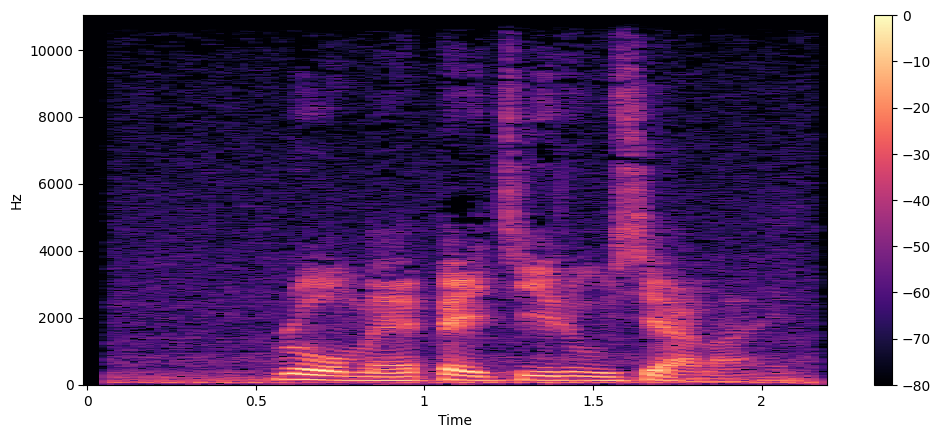

In [20]:
import numpy as np

# -----------------------------
# 1. 使用 STFT 得到 Spectrogram
# -----------------------------

# STFT = Short-Time Fourier Transform（短时傅里叶变换）
# 将整段音频切成很多短时间片，
# 对每个时间片分别做 Fourier Transform
# 得到每个时间点对应的频率信息
D = librosa.stft(array)


# -----------------------------
# 2. 提取频率强度，并转换成 dB
# -----------------------------

# STFT 的输出 D 是 complex numbers
# np.abs(D) 提取每个 时间 × 频率 位置上的 magnitude / amplitude
#
# amplitude_to_db() 再把 amplitude 转成 dB
# 作用：压缩动态范围，让较弱的频率成分更容易观察
# ref=np.max：以整个 spectrogram 中最大的 amplitude 作为 0 dB
S_db = librosa.amplitude_to_db(
    np.abs(D),
    ref=np.max
)


# -----------------------------
# 3. 绘制 Spectrogram
# -----------------------------

# 设置图像宽度
plt.figure().set_figwidth(12)

# 绘制 spectrogram
# x_axis="time"：X轴显示时间
# y_axis="hz"：Y轴显示频率，单位 Hz
# 颜色表示该时间、该频率位置的 amplitude (dB)
librosa.display.specshow(
    S_db,
    x_axis="time",
    y_axis="hz"
)

# 添加颜色条
# 显示不同颜色分别对应多少 dB
plt.colorbar()

In [ ]:

#         t1     t2     t3     t4
# f1      -60    -40    -20    -50
# f2      -50    -10    -30    -60
# f3      -70    -50     0     -40
# ...

# 0 dB      → 最亮 → 最强
# -20 dB    → 较强
# -50 dB    → 较弱
# -80 dB    → 最暗 → 很弱